# 02 - Preprocessing

This notebook demonstrates the full preprocessing API implemented in
`aquinas_toolkit.preprocessing`.

**Pipeline order:** event discovery -> signal filtering -> zeroing -> alignment -> split NN inputs -> quicklooks

References:

- organizer guidance (April 2 and April 9, 2026) is summarised in
  `docs/README.md`
- code-level decisions and config knobs are documented in
  `aquinas_toolkit/preprocessing/README.md`
- the R counterpart this adapts is `AQUINAS_Explorer.R`, shared on
  April 9, 2026


In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

from aquinas_toolkit import AquinasReader
from aquinas_toolkit.cli.run import run_command
from aquinas_toolkit.preprocessing import (
    align_event_group,
    bandpass_filter_waveform_matrix,
    filter_loaded_event_group,
    find_common_sensor_events,
    find_events,
    load_common_event_waveform_matrix,
    load_event_group,
    load_nn_input_arrays,
    load_sensor_map,
    open_preprocess_store,
    plot_nn_input_event,
    random_event_indices,
    summarize_min_duration_filter,
    summarize_nn_inputs,
    zero_loaded_event_group,
)
from aquinas_toolkit.utils.run_management import resolve_run, stage_output_dir


In [2]:
# ---------------------------------------------------------------------------
# Dataset and filter constants
# ---------------------------------------------------------------------------
DATASET_ROOT = Path("..") / "AQUINAS_DATASET"
SAMPLE_RATE_HZ = 100.0
LOW_HZ = 0.5
HIGH_HZ = 20.0
MIN_DURATION_SECONDS = 10.0
EXAMPLE_DECK = "OLD"

# Reader for SET1 (used for acceleration examples)
set1_dir = DATASET_ROOT / "AQUINAS_SET1_2022_07"
reader = AquinasReader(set1_dir)

# Two organizer-shared timestamps used as running examples throughout this notebook
shared_timestamps = [
    "2022-07-02 03:34:40",   # SET1 OLD STR event
    "2022-07-30 18:36:53",   # SET1 OLD ACC_Z event
]

## 1 — Event discovery

### Organizer-style event lookup

The original R script selects events by providing a timestamp that falls
inside the recording window.  Exploratory calls can use exact
`Start_Time` / `End_Time` grouping, while the batch preprocess run now
uses `preprocessing.event_grouping.method=shared_start` by default:
deck + `Start_Time`, with event end recorded as the maximum grouped
`End_Time`. Timestamp filters then return events whose window satisfies
`Start_Time < timestamp < End_Time` (strict containment, not inclusive).

In [3]:
# Find all OLD-deck strain events that contain the first shared timestamp
strain_events = find_events(
    reader,
    timestamp=shared_timestamps[0],
    deck="OLD",
    sensor_pattern="STR",
)
strain_events.head()

,event_id,set_name,deck,start_time_utc,end_time_utc,active_sensor_count,active_sensors
0,AQUINAS_SET1_2022_07__OLD__2022-07-02T03-34-37...,AQUINAS_SET1_2022_07,OLD,2022-07-02 03:34:37+00:00,2022-07-02 03:34:49+00:00,12,"[OLD_S1_DO_INF_STR, OLD_S1_DO_SHE_STR, OLD_S1_..."


### Duration-based record filtering (ACC_Z)

Short recording windows cannot resolve the structural frequency range
(roughly 2–10 Hz).  `summarize_min_duration_filter` reports how many
records survive a minimum-duration threshold across every dataset.  This
filter is applied before FDD analysis and before loading multichannel
event matrices.

In [4]:
set_summaries = []

for set_dir in sorted(DATASET_ROOT.glob("AQUINAS_SET*")):
    r = AquinasReader(set_dir)
    sensor_summary = summarize_min_duration_filter(
        r,
        min_duration_seconds=MIN_DURATION_SECONDS,
        quantity="ACC",
        axis="Z",
    )
    set_summaries.append(
        {
            "Dataset": r.set_name,
            "Sensors": len(sensor_summary),
            "Total records": int(sensor_summary["record_count"].sum()),
            "Kept": int(sensor_summary["kept_count"].sum()),
            "Removed": int(sensor_summary["removed_count"].sum()),
            "Kept %": sensor_summary["kept_count"].sum() / sensor_summary["record_count"].sum(),
        }
    )
    display(
        sensor_summary[
            ["sensor_name", "deck", "span", "side", "location",
             "record_count", "kept_count", "removed_count", "kept_fraction"]
        ]
        .rename(columns={
            "sensor_name": "Sensor", "deck": "Deck", "span": "Span",
            "side": "Side", "location": "Location",
            "record_count": "Total", "kept_count": "Kept",
            "removed_count": "Removed", "kept_fraction": "Kept %",
        })
        .style.hide(axis="index")
        .format({"Total": "{:,.0f}", "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Kept %": "{:.1%}"})
        .set_caption(
            f"{r.set_name} — ACC_Z records kept after minimum-duration filter"
            f" ({MIN_DURATION_SECONDS:.0f} s)"
        )
    )

display(
    pd.DataFrame(set_summaries)
    .style.hide(axis="index")
    .format({
        "Sensors": "{:,.0f}", "Total records": "{:,.0f}",
        "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Kept %": "{:.1%}",
    })
    .set_caption(
        f"ACC_Z minimum-duration filter summary across all datasets"
        f" ({MIN_DURATION_SECONDS:.0f} s threshold)"
    )
)

Sensor,Deck,Span,Side,Location,Total,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,632","3,630",2,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,632","3,630",2,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,633","3,630",3,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,633","3,630",3,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,632","3,630",2,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,632","3,630",2,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,633","3,630",3,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,633","3,630",3,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,948","3,946",2,99.9%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,948","3,946",2,99.9%


Sensor,Deck,Span,Side,Location,Total,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"1,678","1,672",6,99.6%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"1,678","1,672",6,99.6%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"1,678","1,672",6,99.6%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"1,678","1,672",6,99.6%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"1,678","1,672",6,99.6%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"1,678","1,672",6,99.6%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"1,678","1,672",6,99.6%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"1,678","1,672",6,99.6%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"2,105","2,104",1,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"2,105","2,104",1,100.0%


Sensor,Deck,Span,Side,Location,Total,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,493","3,492",1,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,493","3,492",1,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,494","3,492",2,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,494","3,492",2,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,493","3,492",1,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,493","3,492",1,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,494","3,492",2,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,494","3,492",2,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,005","3,005",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,006","3,005",1,100.0%


Sensor,Deck,Span,Side,Location,Total,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,867,866,1,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,867,866,1,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,867,866,1,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,867,866,1,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,867,866,1,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,867,866,1,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,867,866,1,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,867,866,1,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"1,479","1,479",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"1,479","1,479",0,100.0%


Sensor,Deck,Span,Side,Location,Total,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"2,577","2,577",0,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"2,577","2,577",0,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"2,577","2,577",0,100.0%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"2,577","2,577",0,100.0%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"2,577","2,577",0,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"2,577","2,577",0,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"2,577","2,577",0,100.0%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"2,577","2,577",0,100.0%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,350","3,350",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,350","3,350",0,100.0%


Dataset,Sensors,Total records,Kept,Removed,Kept %
AQUINAS_SET1_2022_07,16,"60,639","60,603",36,99.9%
AQUINAS_SET2_2023_04,16,"30,264","30,208",56,99.8%
AQUINAS_SET3_2023_08,16,"51,990","51,972",18,100.0%
AQUINAS_SET4_2024_01,16,"18,768","18,760",8,100.0%
AQUINAS_SET5_2024_06,16,"47,416","47,416",0,100.0%


### Common-event discovery across sensors

`find_common_sensor_events` returns only those event windows where
every selected sensor has a surviving record after duration filtering —
a prerequisite for multichannel FDD analysis.

In [5]:
common_events = find_common_sensor_events(
    reader,
    min_duration_seconds=MIN_DURATION_SECONDS,
    quantity="ACC",
    axis="Z",
    deck=EXAMPLE_DECK,
)

common_event_preview = common_events.head(10).copy()
common_event_preview["sensor_names"] = common_event_preview["sensor_names"].map(
    lambda sensors: ", ".join(sensors)
)

display(Markdown(f"### {reader.set_name} | {EXAMPLE_DECK}"))
display(
    common_event_preview
    .rename(columns={
        "Start_Time": "Start time",
        "End_Time": "End time",
        "sensor_count": "Sensor count",
        "channel_count": "Channel count",
        "sensor_names": "Sensors",
    })
    .style.hide(axis="index")
    .format({"Sensor count": "{:,.0f}", "Channel count": "{:,.0f}"})
    .set_caption(
        f"{reader.set_name} | {EXAMPLE_DECK}"
        f" - first common ACC_Z events after duration filtering"
    )
)


### AQUINAS_SET1_2022_07 | OLD

Start time,End time,Sensor count,Sensors,dataset,deck,Channel count
2022-07-01 01:47:16,2022-07-01 01:47:31,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 02:09:21,2022-07-01 02:09:34,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 02:43:04,2022-07-01 02:43:19,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 02:44:53,2022-07-01 02:45:07,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 02:57:59,2022-07-01 02:58:13,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 03:02:01,2022-07-01 03:02:16,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 03:33:41,2022-07-01 03:33:55,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 03:46:08,2022-07-01 03:46:20,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 03:50:29,2022-07-01 03:50:42,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8
2022-07-01 03:53:42,2022-07-01 03:53:54,8,"OLD_S1_DO_INT_ACC_Z, OLD_S1_DO_MID_ACC_Z, OLD_S1_UP_INT_ACC_Z, OLD_S1_UP_MID_ACC_Z, OLD_S2_DO_INT_ACC_Z, OLD_S2_DO_MID_ACC_Z, OLD_S2_UP_INT_ACC_Z, OLD_S2_UP_MID_ACC_Z",AQUINAS_SET1_2022_07,OLD,8


## 2 — Signal filtering (0.5–20 Hz zero-phase Butterworth)

Signal filtering is the **first conditioning step**, applied directly to
raw waveforms before any baseline correction or alignment.  Filtering
on the raw signal ensures that neither the DC offset nor the alignment
process can introduce artefacts into the passband.

The batch pipeline applies `filter_loaded_event_group()` per sensor
slice.  The cell below also demonstrates `bandpass_filter_waveform_matrix()`
on a wide-format multichannel matrix, which is the entry point used for
FDD analysis in notebook `03_feature_extraction`

In [6]:
# Load the first common event as a multichannel matrix and apply the band-pass filter
example_event = common_events.iloc[0]

waveform_matrix = load_common_event_waveform_matrix(
    reader,
    start_time=example_event["Start_Time"],
    end_time=example_event["End_Time"],
    sensor_names=example_event["sensor_names"],
)
filtered_matrix = bandpass_filter_waveform_matrix(
    waveform_matrix,
    sampling_rate_hz=SAMPLE_RATE_HZ,
    low_hz=LOW_HZ,
    high_hz=HIGH_HZ,
)

display(
    waveform_matrix.head()
    .style.hide(axis="index")
    .set_caption(f"{reader.set_name} | {EXAMPLE_DECK} — raw waveform matrix (first 5 rows)")
)
display(
    filtered_matrix.head()
    .style.hide(axis="index")
    .set_caption(
        f"{reader.set_name} | {EXAMPLE_DECK}"
        f" — zero-phase {LOW_HZ}–{HIGH_HZ} Hz filtered waveform matrix (first 5 rows)"
    )
)

timestamp,OLD_S1_DO_INT_ACC_Z,OLD_S1_DO_MID_ACC_Z,OLD_S1_UP_INT_ACC_Z,OLD_S1_UP_MID_ACC_Z,OLD_S2_DO_INT_ACC_Z,OLD_S2_DO_MID_ACC_Z,OLD_S2_UP_INT_ACC_Z,OLD_S2_UP_MID_ACC_Z
2022-07-01 01:47:16.446,1.005900,1.029900,1.030600,1.029900,1.019000,1.023500,1.015300,1.037500
2022-07-01 01:47:16.456,1.006000,1.030100,1.030200,1.029100,1.019600,1.022900,1.015500,1.037300
2022-07-01 01:47:16.466,1.005700,1.030100,1.030200,1.029500,1.017800,1.022200,1.016100,1.037900
2022-07-01 01:47:16.476,1.004100,1.029400,1.030200,1.029300,1.015900,1.023700,1.017100,1.038700
2022-07-01 01:47:16.486,1.008100,1.028800,1.030800,1.029700,1.017600,1.024700,1.017300,1.039400


timestamp,OLD_S1_DO_INT_ACC_Z,OLD_S1_DO_MID_ACC_Z,OLD_S1_UP_INT_ACC_Z,OLD_S1_UP_MID_ACC_Z,OLD_S2_DO_INT_ACC_Z,OLD_S2_DO_MID_ACC_Z,OLD_S2_UP_INT_ACC_Z,OLD_S2_UP_MID_ACC_Z
2022-07-01 01:47:16.446,0.000317,0.000004,0.000004,-0.000056,-0.000047,0.000040,0.000073,0.000005
2022-07-01 01:47:16.456,-0.000314,0.000184,-0.000312,-0.000503,-0.000490,-0.000589,0.000391,0.000019
2022-07-01 01:47:16.466,-0.000333,0.000013,-0.000422,-0.000663,-0.001139,-0.000701,0.000947,0.000371
2022-07-01 01:47:16.476,0.000396,-0.000442,-0.000291,-0.000531,-0.001808,-0.000265,0.001607,0.001028
2022-07-01 01:47:16.486,0.001272,-0.000779,-0.000059,-0.000339,-0.002093,0.000378,0.001956,0.001640


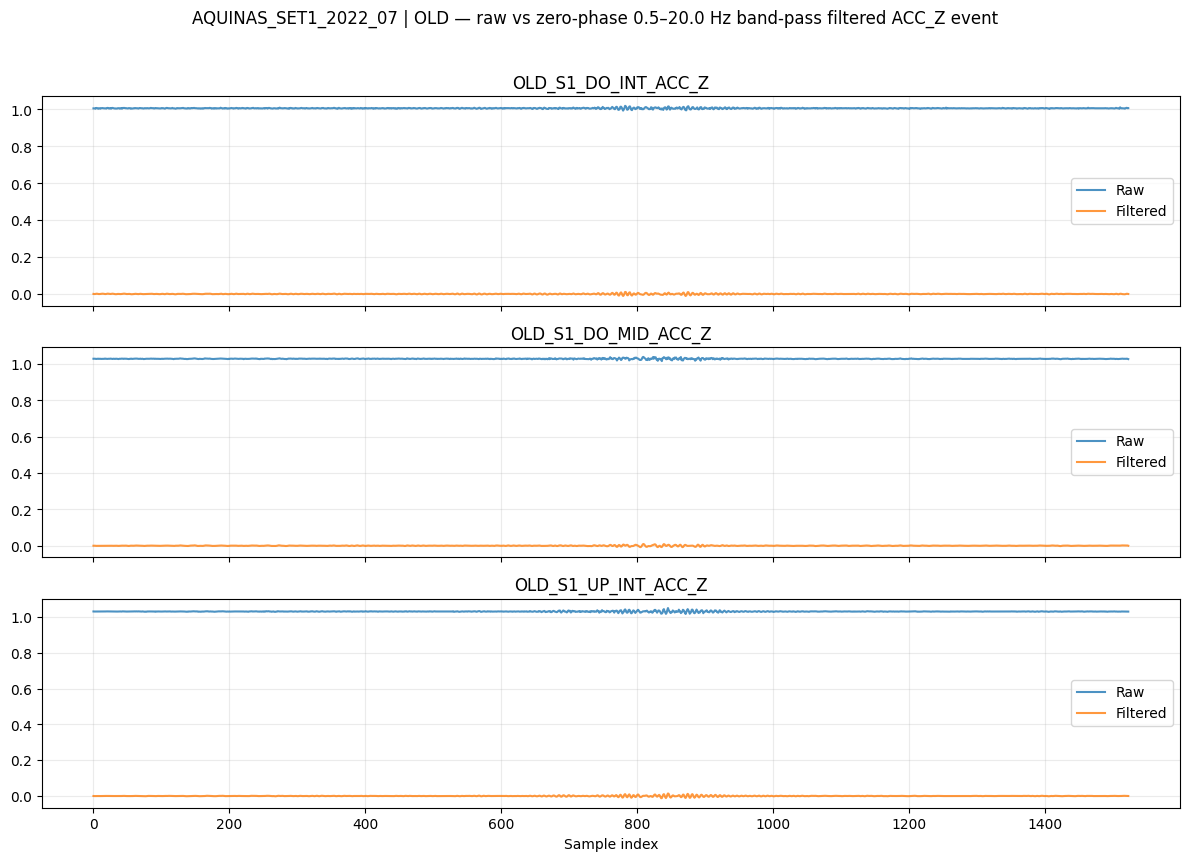

In [7]:
# Raw vs filtered overlay for the first three channels
channels = [c for c in waveform_matrix.columns if c != "timestamp"]
plot_channels = channels[: min(3, len(channels))]

fig, axes = plt.subplots(len(plot_channels), 1, figsize=(12, 2.8 * len(plot_channels)), sharex=True)
if len(plot_channels) == 1:
    axes = [axes]

for ax, ch in zip(axes, plot_channels, strict=True):
    ax.plot(waveform_matrix.index, waveform_matrix[ch], label="Raw", alpha=0.8)
    ax.plot(filtered_matrix.index, filtered_matrix[ch], label="Filtered", alpha=0.8)
    ax.set_title(ch)
    ax.grid(alpha=0.25)
    ax.legend()

axes[-1].set_xlabel("Sample index")
fig.suptitle(
    f"{reader.set_name} | {EXAMPLE_DECK}"
    f" — raw vs zero-phase {LOW_HZ}–{HIGH_HZ} Hz band-pass filtered ACC_Z event",
    y=1.02,
)
fig.tight_layout()
plt.show()

## 3 — Zeroing (baseline correction)

Zeroing removes the linear trend connecting the first and last sample
of each sensor slice.  It is applied **after filtering** so that the
baseline estimate stays within the filtered band.

For well-filtered signals (where the 0.5 Hz high-pass already removes
most of the DC baseline) the correction is small.  It still matters for
filter edge effects — `sosfiltfilt` boundary samples that do not fully
settle — and for near-cutoff residuals in short recordings.

### Organizer-style multi-sensor strain event (SET2)

The organizer material shows many strain sensors overlaid on a shared
time axis.  The cells below reproduce that style for a real SET2 event
on the OLD deck recorded around `2023-04-20 07:04:05 UTC`.

The query timestamp `07:04:10` is used because `find_events` applies
strict containment (`Start_Time < timestamp < End_Time`); the boundary
value itself returns nothing.

The article figure is closer to an unfiltered visualization than to the
fully conditioned preprocessing output.  To make that distinction
explicit, the next plot keeps the organizer-faithful `zeroing +
alignment` steps but intentionally skips the band-pass filter.

We query `2023-04-20 07:04:10 UTC` because `find_events` uses strict
containment, so the boundary start time is excluded.  The selected
OLD-deck event itself starts around `2023-04-20 07:04:05 UTC`.

This does not match the article exactly, but it should be visually
closer to the article figure than the fully filtered view that follows.

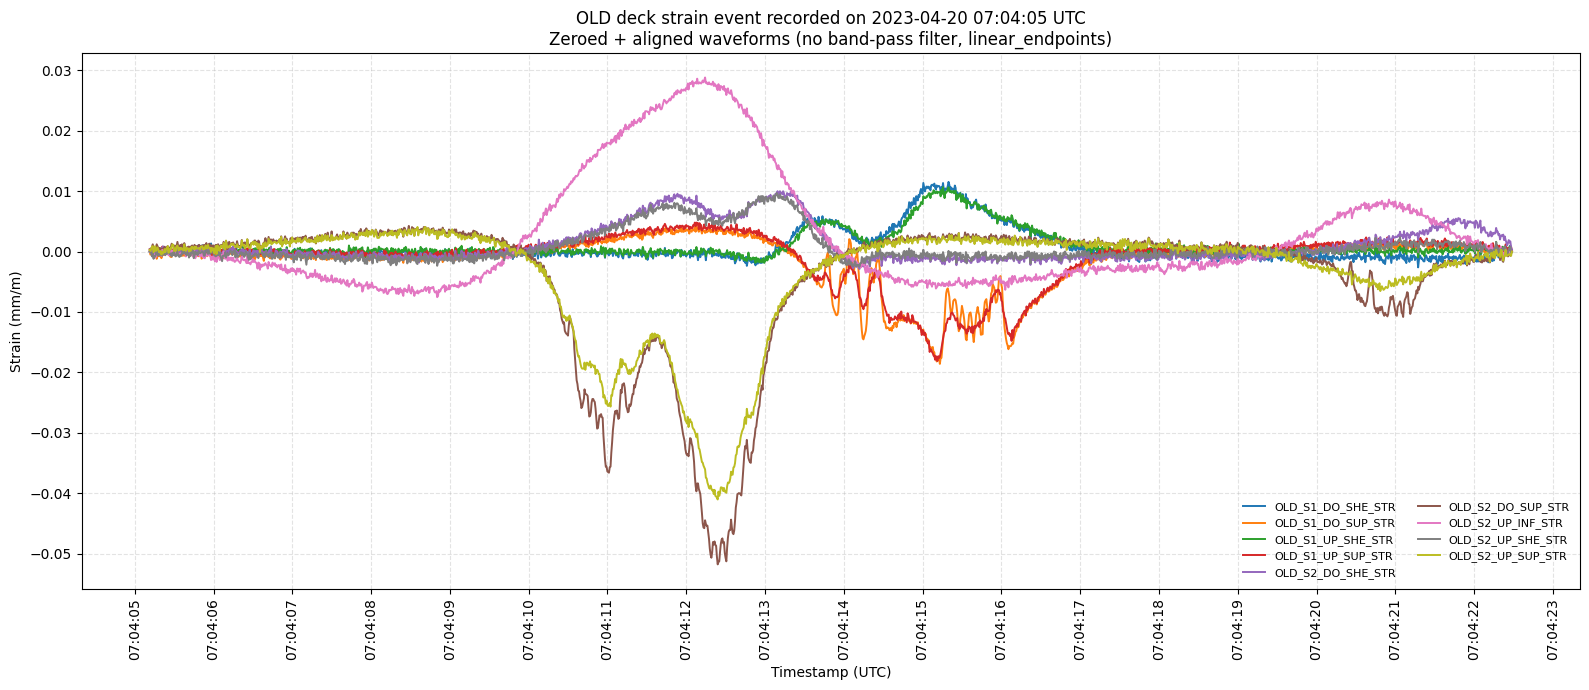

In [8]:
organizer_reader = AquinasReader(DATASET_ROOT / "AQUINAS_SET2_2023_04")
organizer_timestamp = "2023-04-20 07:04:10"

organizer_events = find_events(
    organizer_reader,
    timestamp=organizer_timestamp,
    deck="OLD",
    sensor_pattern="STR",
)
if organizer_events.empty:
    raise ValueError(f"No OLD-deck strain event found for {organizer_timestamp} in SET2.")

organizer_event = organizer_events.iloc[0]

# Load all sensors (no upstream-only filter) to match the organizer article figure
organizer_upstream_loaded = load_event_group(organizer_reader, organizer_event)

# Comparison stage: zero → align (no filtering)
organizer_upstream_zeroed = zero_loaded_event_group(organizer_upstream_loaded)
organizer_upstream_zeroed_aligned = align_event_group(organizer_upstream_zeroed)
upstream_frame = organizer_upstream_zeroed_aligned.aligned_waveform
upstream_sensor_columns = [c for c in upstream_frame.columns if c != "timestamp_utc"]

fig, ax = plt.subplots(figsize=(16, 7))
for sensor in upstream_sensor_columns:
    ax.plot(upstream_frame["timestamp_utc"], upstream_frame[sensor], linewidth=1.4, label=sensor)
ax.set_title(
    "OLD deck strain event recorded on 2023-04-20 07:04:05 UTC\n"
    f"Zeroed + aligned waveforms (no band-pass filter, {organizer_upstream_zeroed_aligned.zeroing_method})"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Strain (mm/m)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()

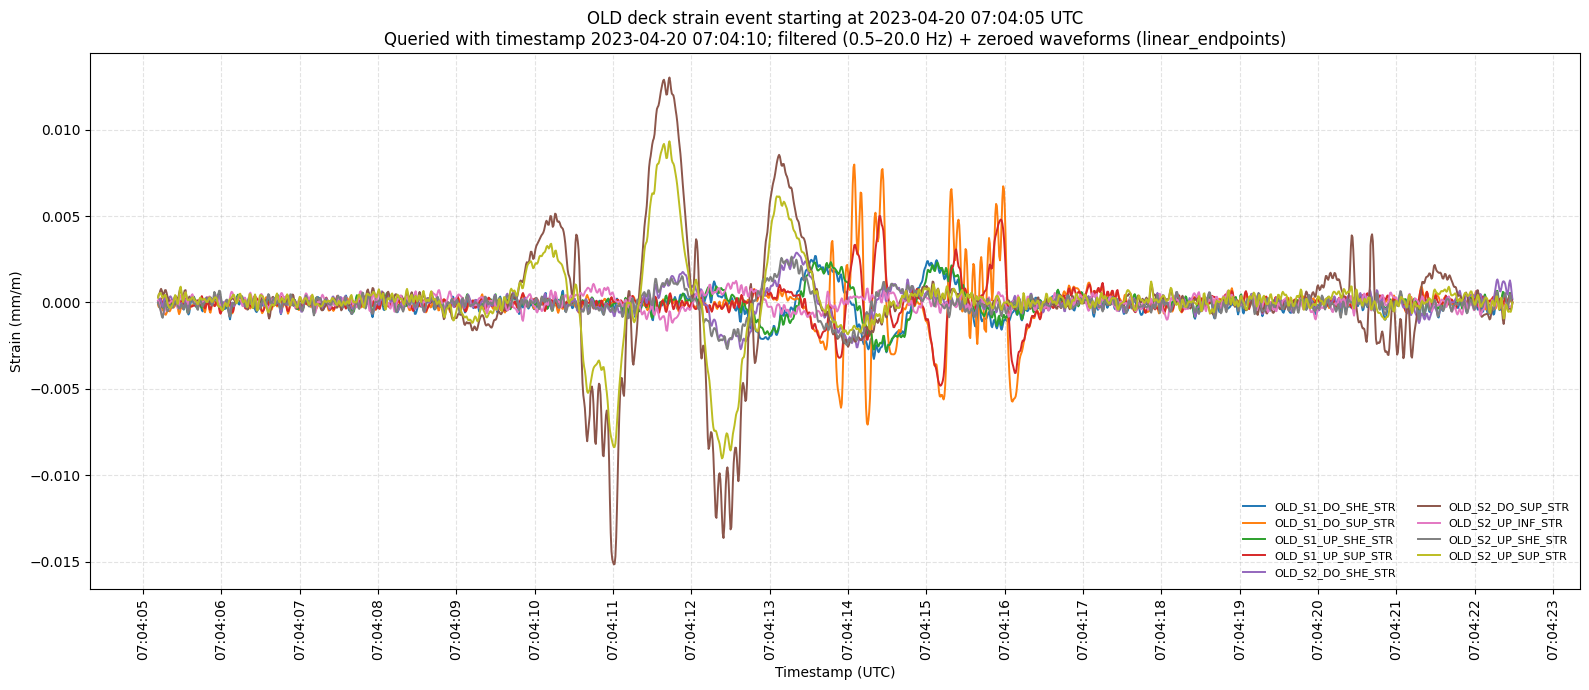

In [9]:
organizer_reader = AquinasReader(DATASET_ROOT / "AQUINAS_SET2_2023_04")
organizer_timestamp = "2023-04-20 07:04:10"

organizer_events = find_events(
    organizer_reader,
    timestamp=organizer_timestamp,
    deck="OLD",
    sensor_pattern="STR",
)
if organizer_events.empty:
    raise ValueError(f"No OLD-deck strain event found for {organizer_timestamp} in SET2.")

organizer_event = organizer_events.iloc[0]
organizer_loaded = load_event_group(organizer_reader, organizer_event)

# Pipeline: filter → zero → align
organizer_filtered = filter_loaded_event_group(organizer_loaded, low_hz=LOW_HZ, high_hz=HIGH_HZ)
organizer_zeroed = zero_loaded_event_group(organizer_filtered)
organizer_zeroed_aligned = align_event_group(organizer_zeroed)
zeroed_frame = organizer_zeroed_aligned.aligned_waveform
organizer_sensor_columns = [c for c in zeroed_frame.columns if c != "timestamp_utc"]

fig, ax = plt.subplots(figsize=(16, 7))
for sensor in organizer_sensor_columns:
    ax.plot(zeroed_frame["timestamp_utc"], zeroed_frame[sensor], linewidth=1.4, label=sensor)
ax.set_title(
    "OLD deck strain event starting at 2023-04-20 07:04:05 UTC\n"
    f"Queried with timestamp {organizer_timestamp}; filtered ({LOW_HZ}\u2013{HIGH_HZ} Hz) + "
    f"zeroed waveforms ({organizer_zeroed_aligned.zeroing_method})"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Strain (mm/m)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()

### Organizer-style Z-acceleration event (SET1)

The organizer material references a Z-acceleration event labeled
`2022-09-01 17:51:55`, which is not present in the released competition
dataset.  The cell below uses the real SET1 upstream ACC_Z event at
`2022-07-30 18:36:53` as a documented substitute; that timestamp is
inside the event window under the organizer's strict containment rule.

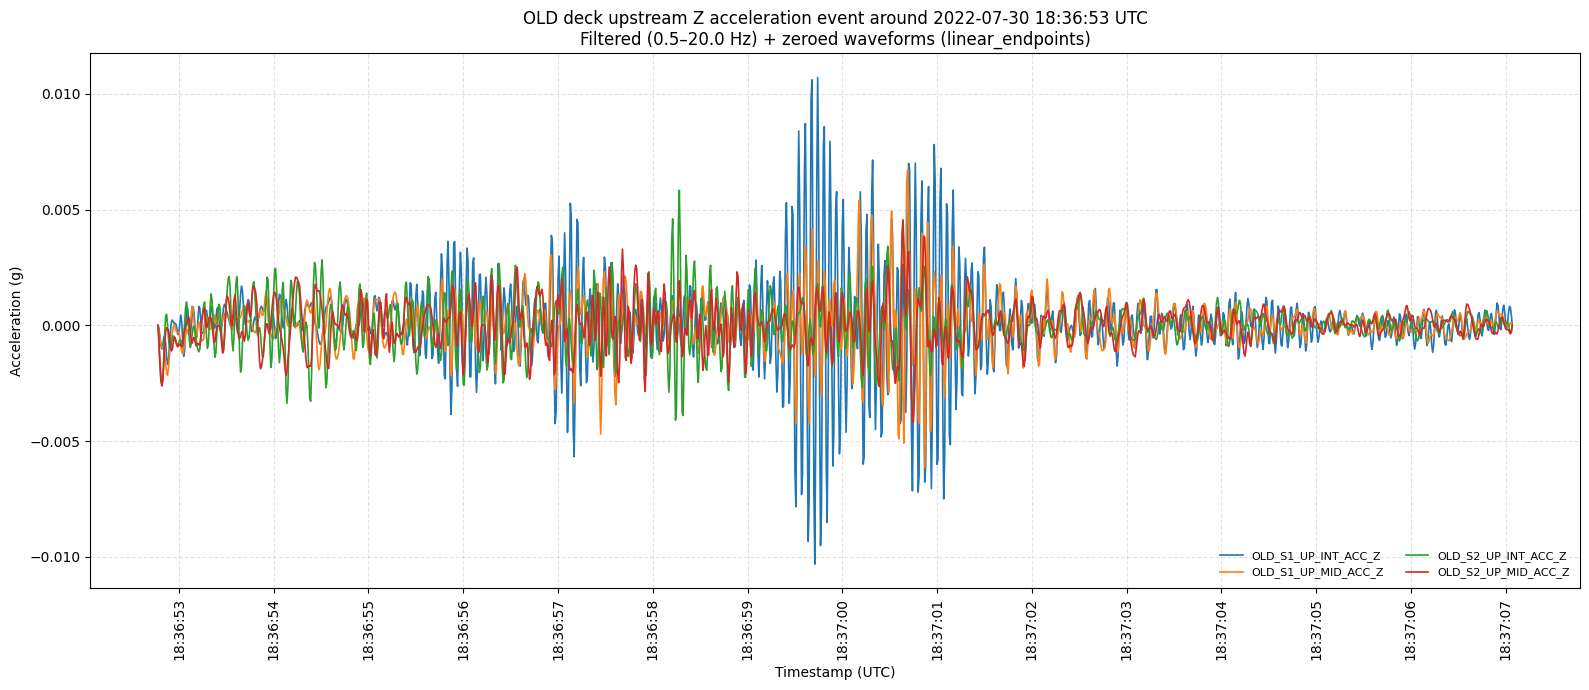

In [10]:
acceleration_timestamp = shared_timestamps[1]  # "2022-07-30 18:36:53"

acceleration_events = find_events(
    reader,
    timestamp=acceleration_timestamp,
    deck="OLD",
    sensor_pattern="*UP*ACC_Z*",
)
if acceleration_events.empty:
    raise ValueError(
        f"No OLD-deck upstream Z acceleration event found for {acceleration_timestamp} in SET1."
    )

acc_loaded = load_event_group(reader, acceleration_events.iloc[0])

# Pipeline: filter → zero → align
acc_filtered = filter_loaded_event_group(acc_loaded, low_hz=LOW_HZ, high_hz=HIGH_HZ)
acc_zeroed = zero_loaded_event_group(acc_filtered)
acc_zeroed_aligned = align_event_group(acc_zeroed)
acc_zeroed_frame = acc_zeroed_aligned.aligned_waveform
acc_sensor_columns = [c for c in acc_zeroed_frame.columns if c != "timestamp_utc"]

fig, ax = plt.subplots(figsize=(16, 7))
for sensor in acc_sensor_columns:
    ax.plot(acc_zeroed_frame["timestamp_utc"], acc_zeroed_frame[sensor], linewidth=1.2, label=sensor)
ax.set_title(
    f"OLD deck upstream Z acceleration event around {acceleration_timestamp} UTC\n"
    f"Filtered ({LOW_HZ}\u2013{HIGH_HZ} Hz) + zeroed waveforms ({acc_zeroed_aligned.zeroing_method})"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Acceleration (g)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()

### OLD-deck ACC_Y view

In the released V1.0 dataset, ACC_Y channels appear on the downstream
side only, so this deck-wide ACC_Y view is effectively the downstream
ACC_Y subset for the same event window.

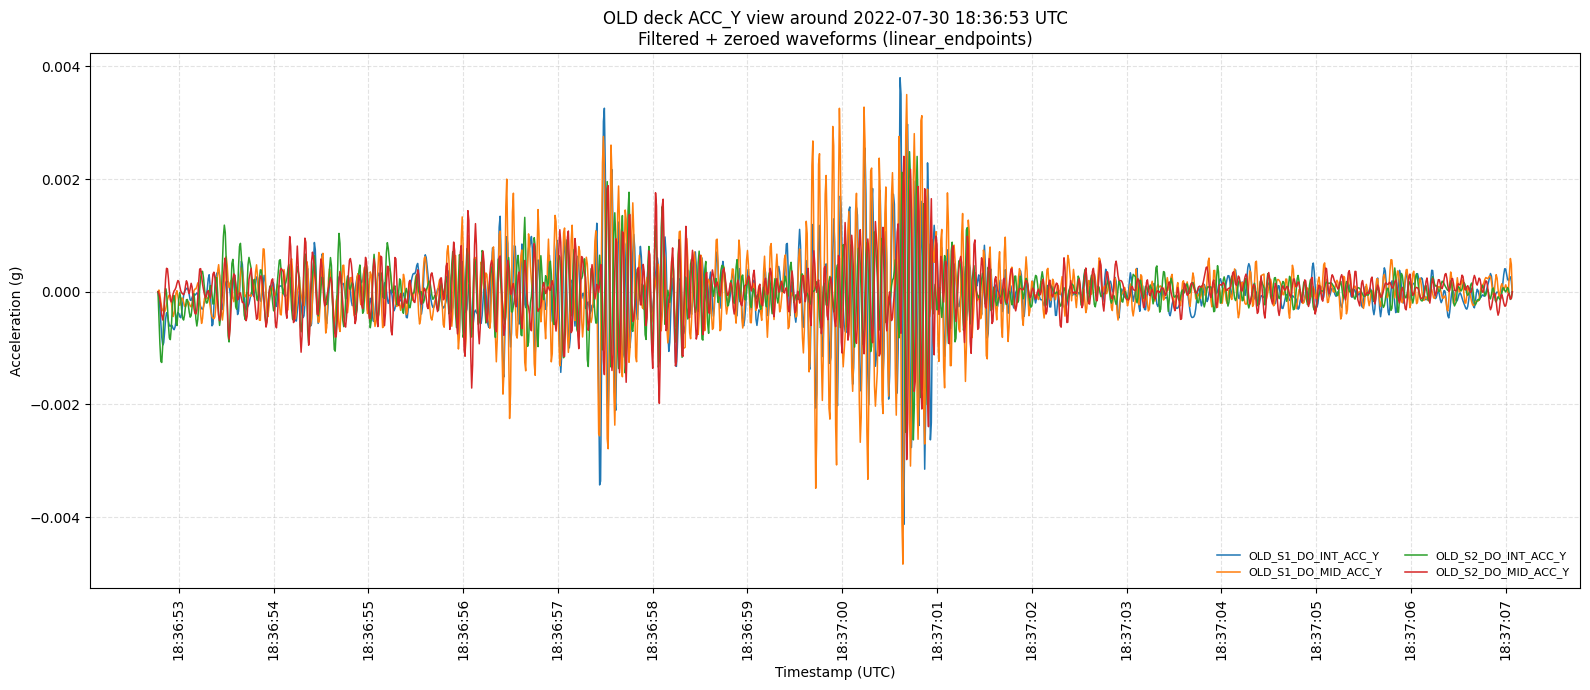

In [11]:
acc_y_events = find_events(
    reader,
    timestamp=acceleration_timestamp,
    deck="OLD",
    sensor_pattern="ACC_Y",
)
if acc_y_events.empty:
    raise ValueError(f"No OLD-deck ACC_Y event found for {acceleration_timestamp} in SET1.")

acc_y_loaded = load_event_group(reader, acc_y_events.iloc[0])
acc_y_filtered = filter_loaded_event_group(acc_y_loaded, low_hz=LOW_HZ, high_hz=HIGH_HZ)
acc_y_zeroed = zero_loaded_event_group(acc_y_filtered)
acc_y_aligned = align_event_group(acc_y_zeroed)
acc_y_frame = acc_y_aligned.aligned_waveform
acc_y_sensors = [c for c in acc_y_frame.columns if c != "timestamp_utc"]

fig, ax = plt.subplots(figsize=(16, 7))
for sensor in acc_y_sensors:
    ax.plot(acc_y_frame["timestamp_utc"], acc_y_frame[sensor], linewidth=1.1, label=sensor)
ax.set_title(
    f"OLD deck ACC_Y view around {acceleration_timestamp} UTC\n"
    f"Filtered + zeroed waveforms ({acc_y_aligned.zeroing_method})"
)
ax.set_xlabel("Timestamp (UTC)")
ax.set_ylabel("Acceleration (g)")
ax.grid(True, linestyle="--", alpha=0.35)
ax.xaxis.set_major_locator(mdates.SecondLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
plt.setp(ax.get_xticklabels(), rotation=90, ha="center")
ax.legend(loc="lower right", fontsize=8, ncol=2, frameon=False)
plt.tight_layout()

## 4 — Timestamp alignment

`align_event_group()` implements the organizer `Synchro()` algorithm:

- the first selected sensor (in organizer order) becomes the reference
- two shrinking passes match every other sensor to the reference
- no interpolation — only exact timestamp matching

The `alignment_diagnostics` field reports how many rows survived each
pass and which sensor was chosen as the reference.

In [12]:
# Show alignment diagnostics from the zeroed strain event
organizer_zeroed_aligned.alignment_diagnostics

{'method': 'r_synchro',
 'reference_sensor': 'OLD_S1_DO_SHE_STR',
 'reference_policy': 'first_selected',
 'passes': 2,
 'rows_reference': 1730,
 'rows_after_alignment': 1727,
 'match_stats': {'OLD_S1_DO_SHE_STR': {'matched_rows': 1727,
   'unmatched_rows': 3},
  'OLD_S1_DO_SUP_STR': {'matched_rows': 1727, 'unmatched_rows': 5},
  'OLD_S1_UP_SHE_STR': {'matched_rows': 1727, 'unmatched_rows': 3},
  'OLD_S1_UP_SUP_STR': {'matched_rows': 1727, 'unmatched_rows': 5},
  'OLD_S2_DO_SHE_STR': {'matched_rows': 1727, 'unmatched_rows': 3},
  'OLD_S2_DO_SUP_STR': {'matched_rows': 1727, 'unmatched_rows': 4},
  'OLD_S2_UP_INF_STR': {'matched_rows': 1727, 'unmatched_rows': 4},
  'OLD_S2_UP_SHE_STR': {'matched_rows': 1727, 'unmatched_rows': 3},
  'OLD_S2_UP_SUP_STR': {'matched_rows': 1727, 'unmatched_rows': 4}}}

## 5 - Batch preprocess outputs: split NN inputs and quicklooks

The cells below run the official preprocess stage from the current
`configs/default.yaml`. This creates a fresh run, writes the canonical
SQLite preprocess store, builds split NN input `.npy` arrays, and then
uses the package quicklook helpers to inspect the event-aligned tensors.

The batch run uses `preprocessing.event_grouping.method=shared_start`: records
with the same deck and `Start_Time` are grouped first, with event end recorded
as the maximum grouped `End_Time`; timestamp alignment then trims the grouped
sensor waveforms to their common overlap. The final neural artifacts are split
by modality, but they share the same event axis: `strain_inputs[i]`,
`acc_inputs[i]`, `temperature_inputs[i]`, and `event_ids[i]` all describe the
same physical event row. The default NN selection keeps `INF_STR`, `SUP_STR`,
and `ACC_Z`; `SHE_STR` and `ACC_Y` are excluded from these tensors.

Re-running this section creates a new run each time. The generated files
live under `results/<run_id>/stages/preprocess/nn_inputs/` and are not
committed to git.


In [13]:
exit_code = run_command(
    stage="preprocess",
    name="notebook_02_preprocessing",
    run_id=None,
    verbose=False,
)
if exit_code:
    raise RuntimeError(f"Preprocess stage failed with exit code {exit_code}.")

run_context = resolve_run()
preprocess_dir = stage_output_dir(run_context.run_dir, "preprocess")
arrays = load_nn_input_arrays(preprocess_dir)

run_paths = pd.DataFrame(
    [
        {"item": "run_id", "value": run_context.run_id},
        {"item": "preprocess_dir", "value": str(preprocess_dir)},
        {"item": "nn_inputs_dir", "value": str(arrays.nn_inputs_dir)},
    ]
)
display(run_paths.style.hide(axis="index"))


╭────────────────────────────────────────────────── Created Run ──────────────────────────────────────────────────╮
│ Run ID: 2026-05-23T16-53-46Z                                                                                    │
│ Run directory: C:\Users\murat\Documents\GitHub\EWSHM_Competition\results\2026-05-23T16-53-46Z                   │
│ Config snapshot: C:\Users\murat\Documents\GitHub\EWSHM_Competition\results\2026-05-23T16-53-46Z\config.yaml     │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

START preprocess Run 2026-05-23T16-53-46Z

Output()

SET 1/1  AQUINAS_SET1_2022_07

done  3,979 retained  0 discarded

Writing preprocess store...

DONE  preprocess Output: C:\Users\murat\Documents\GitHub\EWSHM_Competition\results\2026-05-23T16-53-46Z\stages\preprocess (total_s=1687.561)

TIP   viz Open the visualization with `aquinas viz open`.

item,value
run_id,2026-05-23T16-53-46Z
preprocess_dir,C:\Users\murat\Documents\GitHub\EWSHM_Competition\results\2026-05-23T16-53-46Z\stages\preprocess
nn_inputs_dir,C:\Users\murat\Documents\GitHub\EWSHM_Competition\results\2026-05-23T16-53-46Z\stages\preprocess\nn_inputs


In [14]:
summary = summarize_nn_inputs(preprocess_dir)
shape_rows = [
    {
        "artifact": name,
        "shape": tuple(shape),
        "finite_count": summary["finite_counts"].get(name, ""),
        "nan_count": summary["nan_counts"].get(name, ""),
    }
    for name, shape in summary["shapes"].items()
]
summary_table = pd.DataFrame(shape_rows)

display(Markdown(f"### NN input summary - {summary['event_count']:,} retained events"))
display(summary_table.style.hide(axis="index"))
display(
    Markdown(
        "Event rows are aligned across artifacts: row `i` in `strain_inputs`, "
        "`acc_inputs`, `temperature_inputs`, and `event_ids` is the same event."
    )
)


### NN input summary - 3,899 retained events

artifact,shape,finite_count,nan_count
strain_inputs,"(3899, 200, 8)",6238400,0
acc_inputs,"(3899, 820, 8)",25577440,0
temperature_inputs,"(3899, 1)",3899,0
event_ids,"(3899,)",,
frequency_bins,"(820,)",,


In [15]:
sensor_map = load_sensor_map(preprocess_dir)
included_channels = sensor_map.loc[sensor_map["include_flag"].astype(bool)].copy()
channel_columns = [
    "model_channel_id",
    "global_model_channel_index",
    "sensor_name",
    "sensor_type",
    "deck",
    "span",
    "side",
    "location",
    "axis_or_type",
]

display(Markdown("### Included NN channel order"))
display(
    included_channels[channel_columns]
    .sort_values("global_model_channel_index")
    .style.hide(axis="index")
)


### Included NN channel order

model_channel_id,global_model_channel_index,sensor_name,sensor_type,deck,span,side,location,axis_or_type
STR00,0.000000,OLD_S1_DO_INF_STR,STR,OLD,S1,DO,INF,INF
STR01,1.000000,OLD_S1_DO_SUP_STR,STR,OLD,S1,DO,SUP,SUP
STR02,2.000000,OLD_S1_UP_INF_STR,STR,OLD,S1,UP,INF,INF
STR03,3.000000,OLD_S1_UP_SUP_STR,STR,OLD,S1,UP,SUP,SUP
STR04,4.000000,OLD_S2_DO_INF_STR,STR,OLD,S2,DO,INF,INF
STR05,5.000000,OLD_S2_DO_SUP_STR,STR,OLD,S2,DO,SUP,SUP
STR06,6.000000,OLD_S2_UP_INF_STR,STR,OLD,S2,UP,INF,INF
STR07,7.000000,OLD_S2_UP_SUP_STR,STR,OLD,S2,UP,SUP,SUP
ACCZ00,8.000000,OLD_S1_DO_INT_ACC_Z,ACC,OLD,S1,DO,INT,Z
ACCZ01,9.000000,OLD_S1_DO_MID_ACC_Z,ACC,OLD,S1,DO,MID,Z


In [ ]:
included_channel_count = len(included_channels)
with open_preprocess_store(preprocess_dir) as store:
    retained_events = store.iter_retained_events()

missing_counts = included_channel_count - retained_events["active_sensor_count"]
coverage_distribution = (
    pd.DataFrame({"missing_selected_sensor_count": range(included_channel_count + 1)})
    .merge(
        missing_counts.value_counts()
        .rename_axis("missing_selected_sensor_count")
        .reset_index(name="event_count"),
        on="missing_selected_sensor_count",
        how="left",
    )
    .fillna({"event_count": 0})
    .astype({"event_count": int})
)

complete_event_count = int((missing_counts == 0).sum())
display(
    Markdown(
        "### Selected-sensor coverage before NN packaging\n"
        f"The current NN selection has `{included_channel_count}` fixed channels. "
        f"`{complete_event_count:,}` retained preprocess events have all selected channels, "
        f"and `{summary['event_count']:,}` rows remain in the final NN tensors after packaging constraints."
    )
)
display(coverage_distribution.style.hide(axis="index"))


### Deterministic random NN input quicklooks

#### Event row `103` - `event_0103.png`

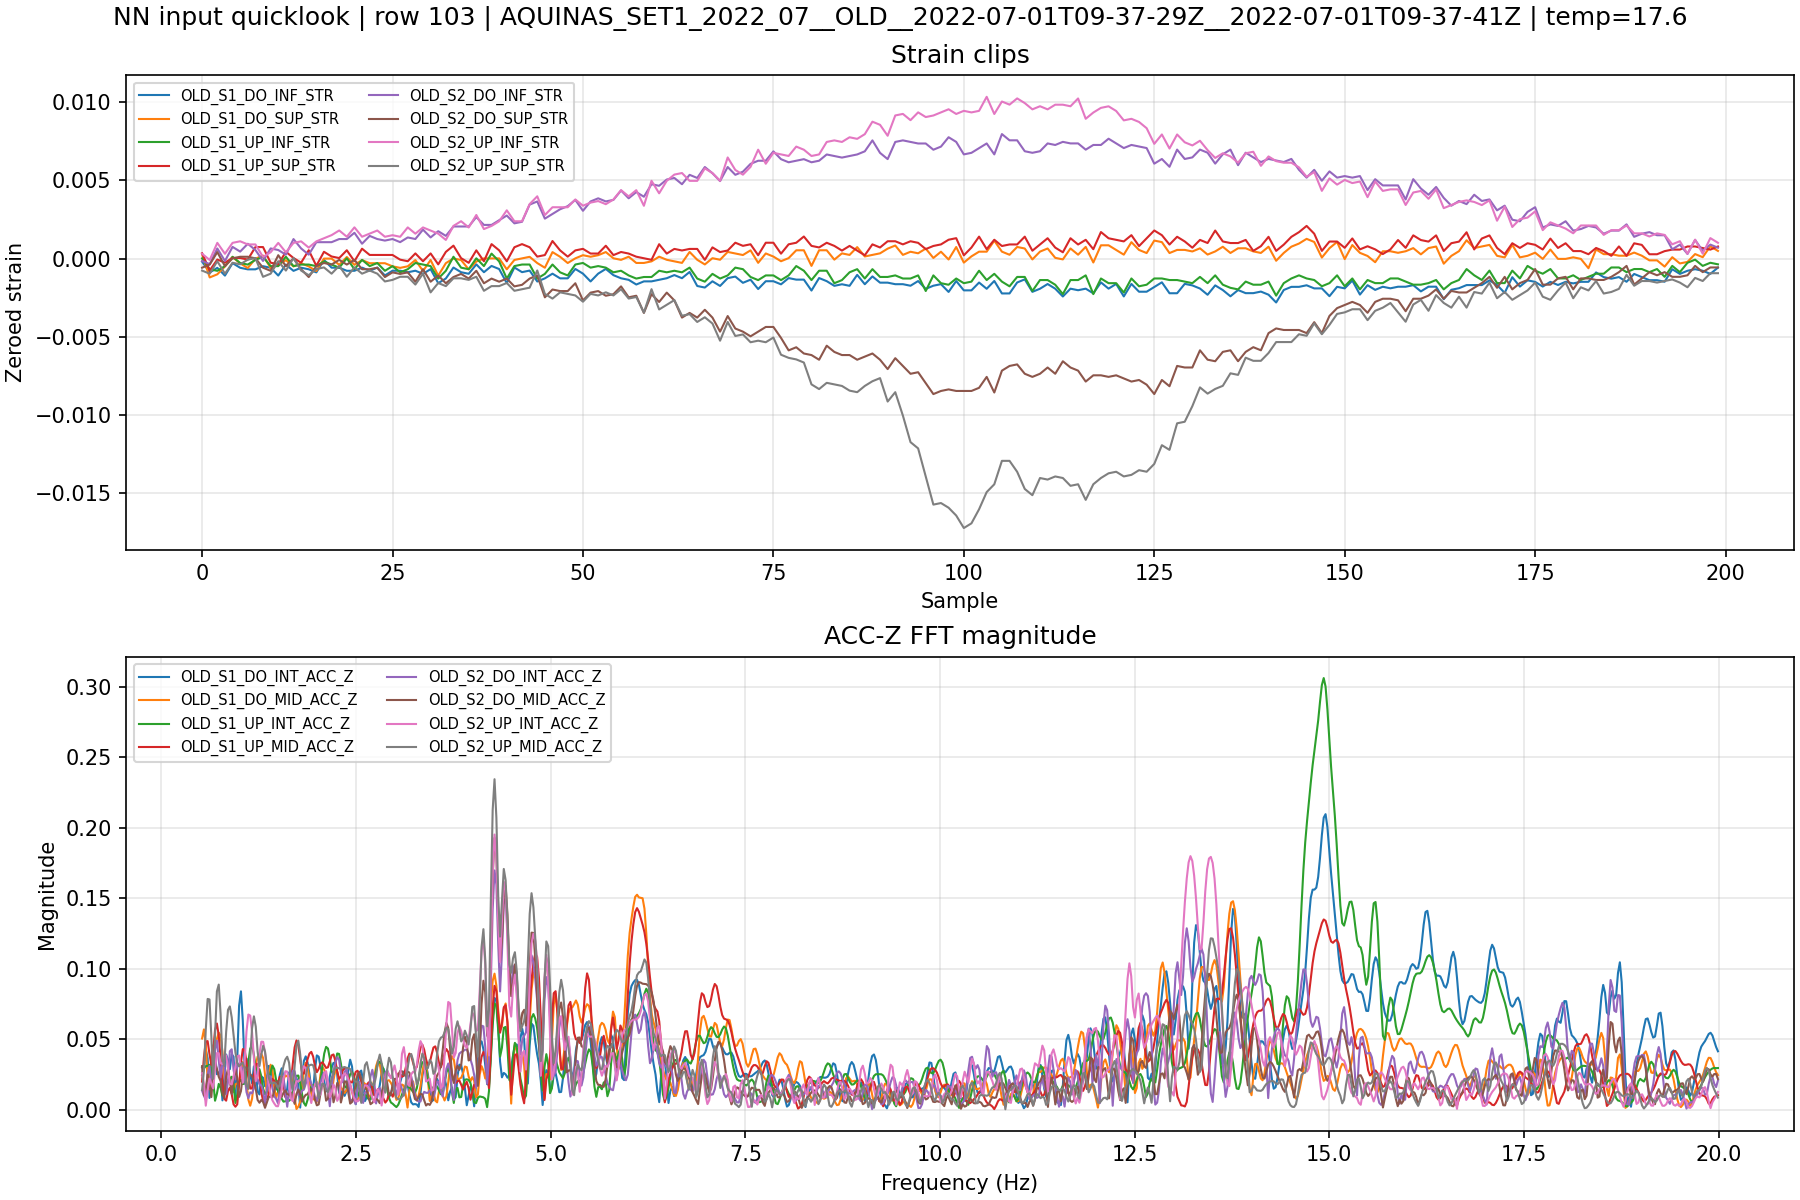

#### Event row `697` - `event_0697.png`

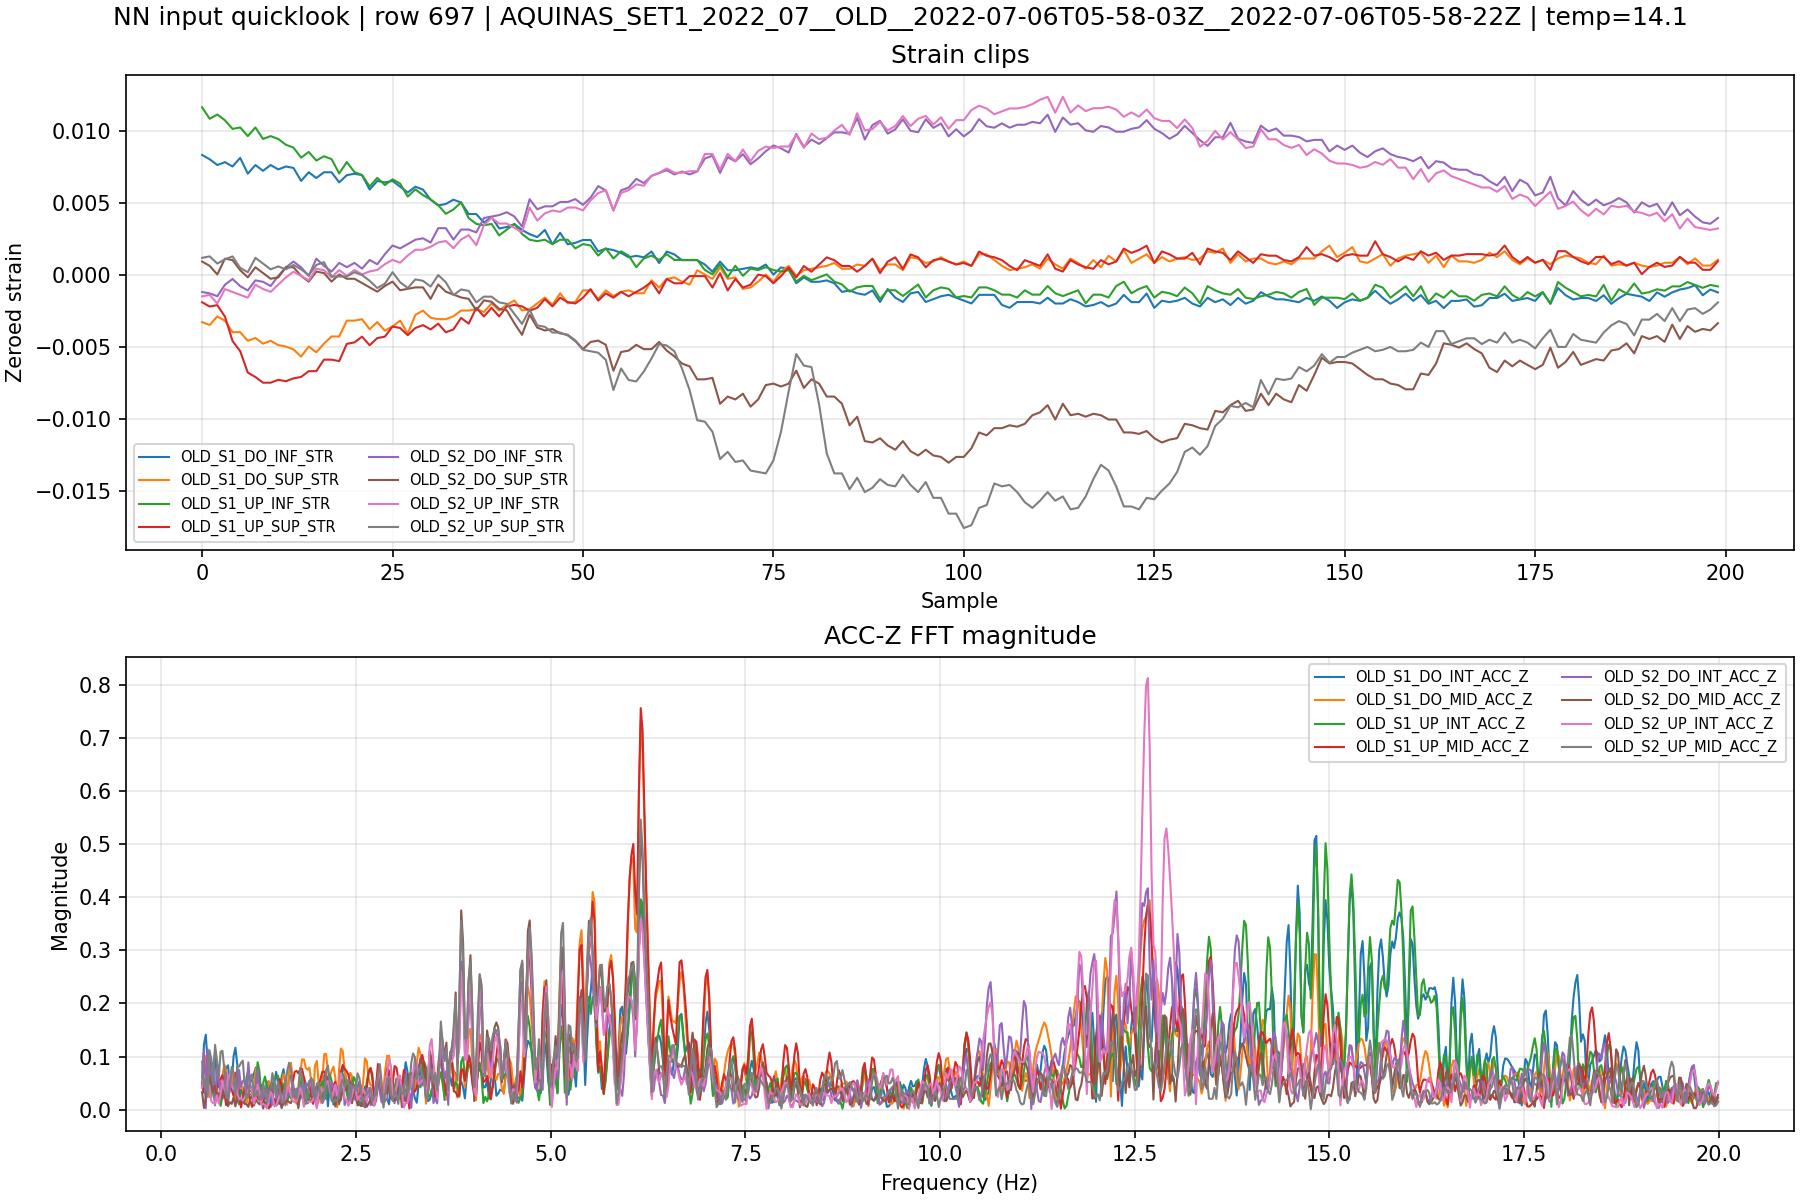

#### Event row `3319` - `event_3319.png`

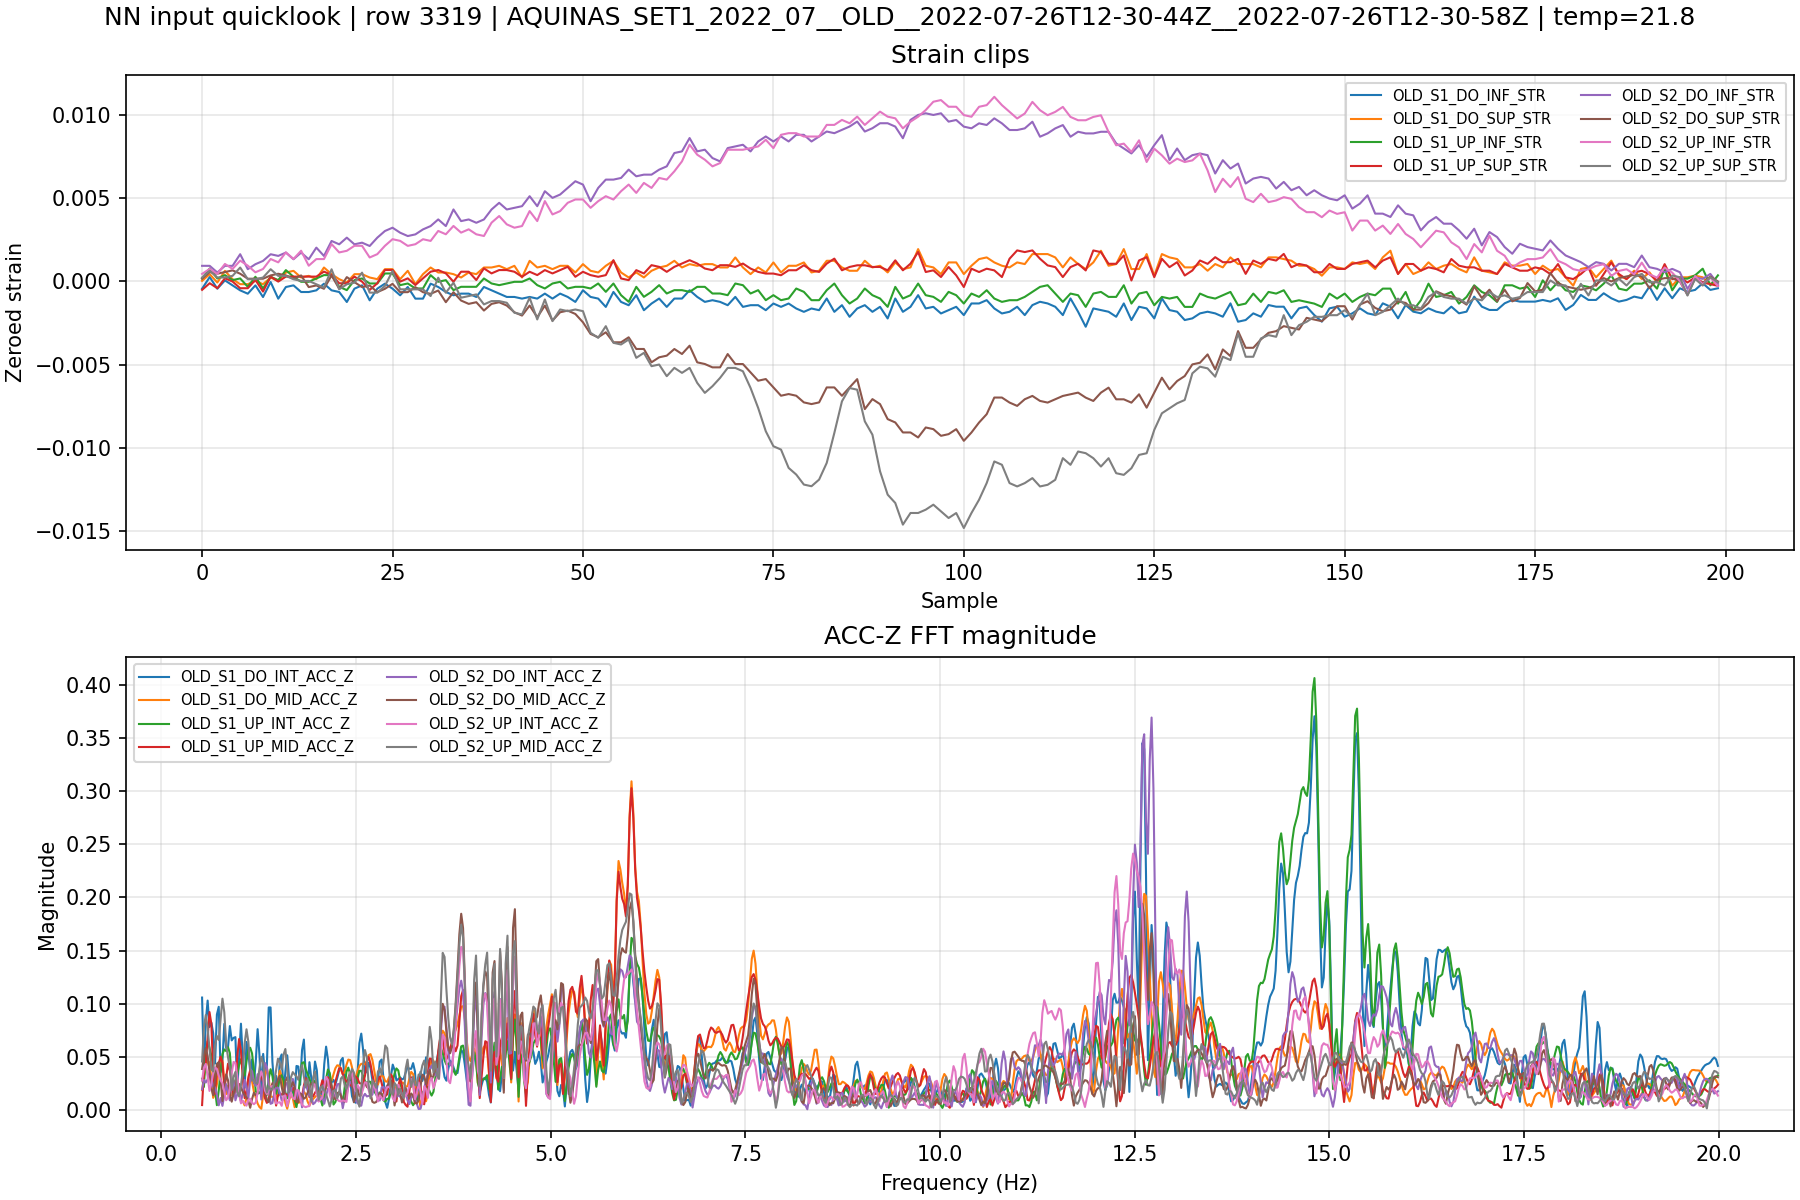

In [16]:
if arrays.event_ids.shape[0] == 0:
    display(Markdown("No retained NN input events were available, so quicklook plotting was skipped."))
else:
    quicklook_indices = random_event_indices(preprocess_dir, count=3, seed=2026)
    quicklook_paths = [
        plot_nn_input_event(preprocess_dir, event_index=index)
        for index in quicklook_indices
    ]

    display(Markdown("### Deterministic random NN input quicklooks"))
    for index, quicklook_path in zip(quicklook_indices, quicklook_paths, strict=True):
        display(Markdown(f"#### Event row `{index}` - `{quicklook_path.name}`"))
        display(Image(filename=str(quicklook_path)))
